# Análise de Retenção de Hóspedes

**Objetivo:** Entender o comportamento de retorno dos hóspedes — quantos voltam, com que frequência e como a retenção evolui ao longo do tempo.

**Base:** Registros de check-in de um hotel resort (dados anonimizados)  
**Período:** Fevereiro/2025 a Maio/2026  
**Ferramentas:** Python · Pandas · Matplotlib

---

## 1. Importações e Configurações

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Estilo visual dos gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e Inspeção dos Dados

In [57]:
df = pd.read_csv('../data/hospedes_anonimizado.csv', sep=';', engine='python')

print(f'Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
print(f'Colunas: {df.columns.tolist()}')
df.head(10)

Dimensões: 29,999 linhas x 5 colunas
Colunas: ['Reserva', 'Hospede', 'Email', 'Contagem de Reserva', 'DataCheckin']


,Reserva,Hospede,Email,Contagem de Reserva,DataCheckin
0,400305,Gustavo Araujo,garaujo@outlook.com,1.0,5/13/26
1,400414,Thiago Carvalho,thiago814@uol.com.br,1.0,5/13/26
2,400108,Fábio Nascimento,fábio.nascimento@gmail.com,1.0,5/13/26
3,400349,Felipe Ramos,felipe438@yahoo.com.br,1.0,5/13/26
4,400184,Luciana Melo,luciana.melo@gmail.com,1.0,5/13/26
5,400142,Isabela Cardoso,isabela9@outlook.com,1.0,5/13/26
6,400048,Patrícia Moreira,pmoreira@uol.com.br,1.0,5/13/26
7,400307,Bruno Santos,bsantos@hotmail.com,1.0,5/13/26
8,400267,Vinícius Pinto,vinícius305@uol.com.br,1.0,5/13/26
9,400301,Fernanda Lima,fernanda129@outlook.com,1.0,5/13/26


In [58]:
# Verificação de nulos por coluna
# isna().sum() conta quantos valores ausentes existem em cada coluna
print('Valores nulos por coluna:')
print(df.isna().sum())
print()
print('Tipos de dados:')
print(df.dtypes)

Valores nulos por coluna:
Reserva                 0
Hospede                 0
Email                   0
Contagem de Reserva    10
DataCheckin            10
dtype: int64

Tipos de dados:
Reserva                  int64
Hospede                 object
Email                   object
Contagem de Reserva    float64
DataCheckin             object
dtype: object


## 3. Limpeza e Padronização

In [59]:
# Padronização do email: remove espaços e converte para minúsculo
# Usamos o email como chave de identificação do hóspede
df['Email'] = df['Email'].astype(str).str.lower().str.strip()

# Conversão da data de check-in para formato datetime
# Isso permite extrair ano, mês e fazer operações de janela temporal
df['DataCheckin'] = pd.to_datetime(df['DataCheckin'], format='%m/%d/%y')

# Criação da coluna Ano para agrupamentos anuais
df['Ano'] = df['DataCheckin'].dt.year

# Remove registros sem data de check-in (não é possível analisar retenção sem ela)
registros_antes = len(df)
df = df.dropna(subset=['DataCheckin'])
registros_removidos = registros_antes - len(df)

print(f'Registros antes da limpeza: {registros_antes:,}')
print(f'Registros removidos (sem data): {registros_removidos:,}')
print(f'Registros após limpeza: {len(df):,}')
print(f'Período: {df["DataCheckin"].min().date()} a {df["DataCheckin"].max().date()}')

Registros antes da limpeza: 29,999
Registros removidos (sem data): 10
Registros após limpeza: 29,989
Período: 2025-02-17 a 2026-05-13


## 4. Indicadores Gerais de Retenção

In [60]:
# Total de hóspedes únicos identificados por email
hospedes_unicos = df['Email'].nunique()

# Recorrência: conta quantas vezes cada email aparece na base
recorrencia = df.groupby('Email').size()

# Hóspedes recorrentes: aparecem mais de uma vez
recorrentes = recorrencia[recorrencia > 1]
total_recorrentes = recorrentes.count()

# Taxa de retenção: proporção de hóspedes que voltaram
taxa_retencao = (total_recorrentes / hospedes_unicos) * 100

print('─' * 40)
print(f'Total de registros:       {len(df):>8,}')
print(f'Hóspedes únicos:          {hospedes_unicos:>8,}')
print(f'Hóspedes recorrentes:     {total_recorrentes:>8,}')
print(f'Taxa de retenção geral:   {taxa_retencao:>7.1f}%')
print('─' * 40)

────────────────────────────────────────
Total de registros:         29,989
Hóspedes únicos:            10,128
Hóspedes recorrentes:          626
Taxa de retenção geral:       6.2%
────────────────────────────────────────


## 5. Retenção por Ano

In [61]:
# Calcula métricas de retenção para cada ano disponível na base
resultados_ano = []

for ano in sorted(df['Ano'].dropna().unique()):
    df_ano = df[df['Ano'] == ano]
    total = len(df_ano)
    unicos = df_ano['Email'].nunique()
    recorrentes_ano = total - unicos
    taxa = (recorrentes_ano / total) * 100 if total > 0 else 0
    resultados_ano.append({
        'Ano': int(ano),
        'Total Check-ins': total,
        'Hóspedes Únicos': unicos,
        'Recorrentes': recorrentes_ano,
        'Taxa Retenção (%)': round(taxa, 1)
    })

df_anos = pd.DataFrame(resultados_ano)
print(df_anos.to_string(index=False))

 Ano  Total Check-ins  Hóspedes Únicos  Recorrentes  Taxa Retenção (%)
2025            21071             7227        13844               65.7
2026             8918             3382         5536               62.1


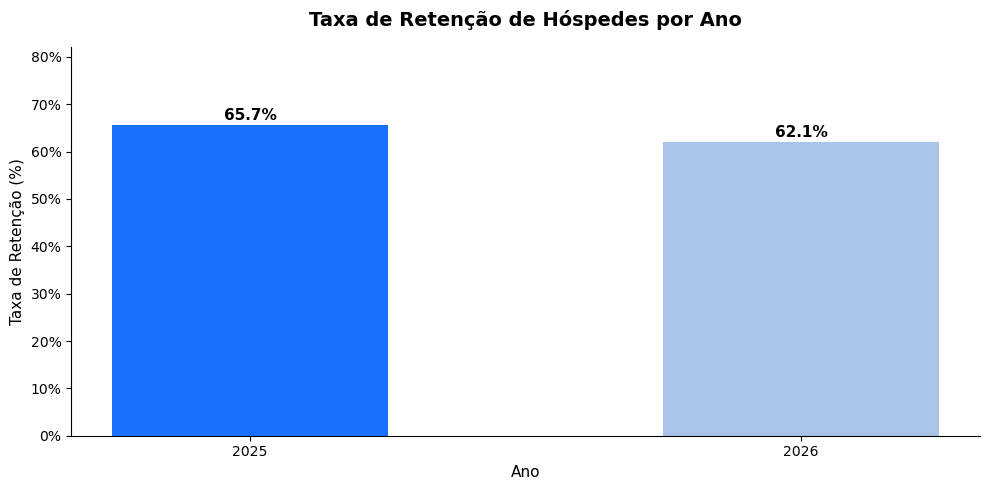

Gráfico salvo em exports/


In [62]:
# Gráfico 1: Taxa de retenção por ano
fig, ax = plt.subplots()

cores = ['#1771FF' if t == df_anos['Taxa Retenção (%)'].max() else '#A8C4E8'
         for t in df_anos['Taxa Retenção (%)']]

bars = ax.bar(
    df_anos['Ano'].astype(str),
    df_anos['Taxa Retenção (%)'],
    color=cores,
    width=0.5,
    edgecolor='none'
)

# Adiciona o valor em cima de cada barra
for bar, val in zip(bars, df_anos['Taxa Retenção (%)']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax.set_title('Taxa de Retenção de Hóspedes por Ano', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Taxa de Retenção (%)', fontsize=11)
ax.set_ylim(0, df_anos['Taxa Retenção (%)'].max() * 1.25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../exports/grafico_retencao_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em exports/')

## 6. Análise de Janela Temporal (Últimos 12 Meses)

In [63]:
# Janela de 12 meses a partir da data mais recente da base
# Útil para medir retenção recente, sem distorção de períodos antigos
data_max = df['DataCheckin'].max()
corte_12m = data_max - pd.DateOffset(months=12)

df_12m = df[df['DataCheckin'] >= corte_12m]

total_12m = len(df_12m)
unicos_12m = df_12m['Email'].nunique()
recorrentes_12m = total_12m - unicos_12m
retencao_12m = (recorrentes_12m / total_12m) * 100

print(f'Período analisado: {corte_12m.date()} a {data_max.date()}')
print('─' * 40)
print(f'Total de check-ins:       {total_12m:>8,}')
print(f'Hóspedes únicos:          {unicos_12m:>8,}')
print(f'Recorrentes:              {recorrentes_12m:>8,}')
print(f'Taxa de retenção 12m:     {retencao_12m:>7.1f}%')
print('─' * 40)

Período analisado: 2025-05-13 a 2026-05-13
────────────────────────────────────────
Total de check-ins:         24,917
Hóspedes únicos:             8,513
Recorrentes:                16,404
Taxa de retenção 12m:        65.8%
────────────────────────────────────────


## 7. Distribuição de Frequência dos Hóspedes

In [64]:
# Conta quantas vezes cada hóspede aparece na base
freq = df.groupby('Email').size().reset_index(name='visitas')

# Classifica em faixas de recorrência (buckets)
bins = [0, 1, 2, 3, 5, float('inf')]
labels = ['1 visita', '2 visitas', '3 visitas', '4-5 visitas', '6+ visitas']

freq['faixa'] = pd.cut(freq['visitas'], bins=bins, labels=labels)

dist = freq['faixa'].value_counts().sort_index()
pct = (dist / dist.sum() * 100).round(1)

df_dist = pd.DataFrame({'Hóspedes': dist, 'Proporção (%)': pct})
print(df_dist)

             Hóspedes  Proporção (%)
faixa                               
1 visita         9502           93.8
2 visitas         221            2.2
3 visitas           5            0.0
4-5 visitas         0            0.0
6+ visitas        400            3.9


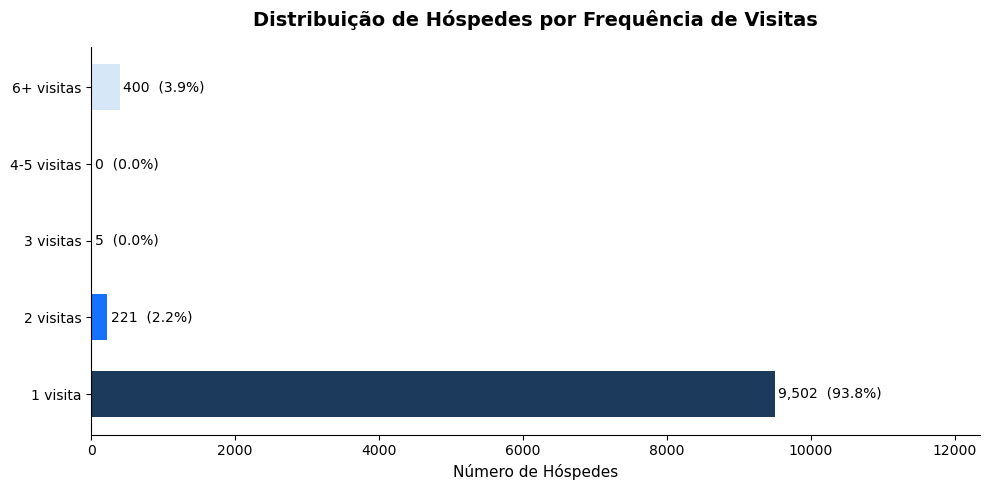

Gráfico salvo em exports/


In [65]:
# Gráfico 2: Distribuição de frequência de visitas
fig, ax = plt.subplots()

cores_dist = ['#1B3A5C', '#1771FF', '#4A90D9', '#A8C4E8', '#D6E8F7']

bars = ax.barh(
    dist.index,
    dist.values,
    color=cores_dist,
    edgecolor='none',
    height=0.6
)

for bar, val, p in zip(bars, dist.values, pct.values):
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({p}%)',
        va='center', fontsize=10
    )

ax.set_title('Distribuição de Hóspedes por Frequência de Visitas', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Número de Hóspedes', fontsize=11)
ax.set_xlim(0, dist.max() * 1.3)

plt.tight_layout()
plt.savefig('../exports/grafico_distribuicao_visitas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em exports/')

## 8. Evolução Mensal de Check-ins

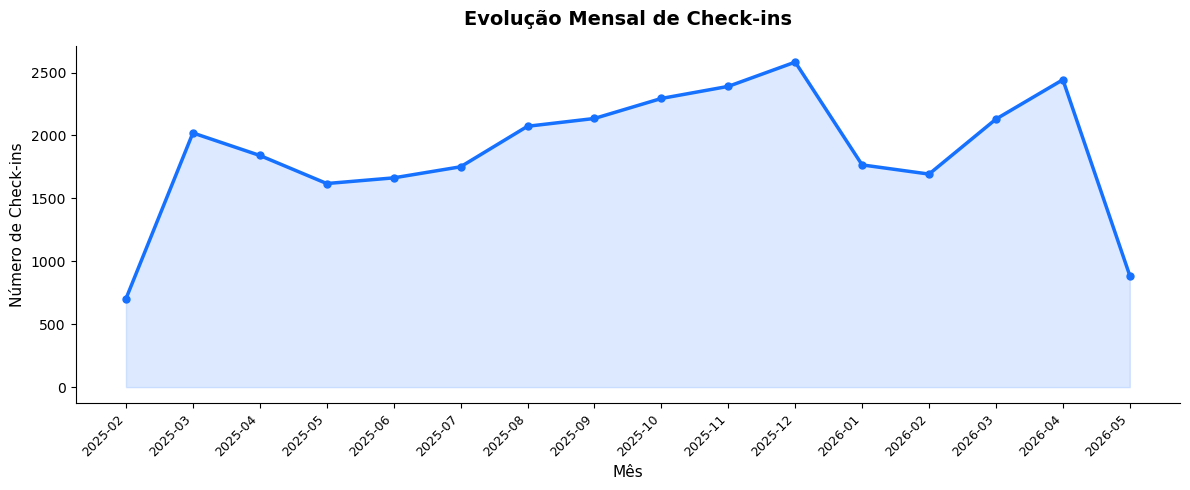

Gráfico salvo em exports/


In [66]:
# Agrupa check-ins por mês para ver sazonalidade e tendência
df['AnoMes'] = df['DataCheckin'].dt.to_period('M')
evolucao = df.groupby('AnoMes').size().reset_index(name='checkins')
evolucao['AnoMes_str'] = evolucao['AnoMes'].astype(str)

# Gráfico 3: Evolução mensal
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(
    range(len(evolucao)),
    evolucao['checkins'],
    alpha=0.15,
    color='#1771FF'
)
ax.plot(
    range(len(evolucao)),
    evolucao['checkins'],
    color='#1771FF',
    linewidth=2.5,
    marker='o',
    markersize=5
)

ax.set_xticks(range(len(evolucao)))
ax.set_xticklabels(evolucao['AnoMes_str'], rotation=45, ha='right', fontsize=9)
ax.set_title('Evolução Mensal de Check-ins', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Número de Check-ins', fontsize=11)

plt.tight_layout()
plt.savefig('../exports/grafico_evolucao_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em exports/')

## 9. Resumo Executivo

| Indicador | Valor |
|---|---|
| Total de registros analisados | 29.989 |
| Hóspedes únicos identificados | 10.128 |
| Taxa de retenção geral | 6,2% |
| Taxa de retenção (últimos 12 meses) | 65,8% |
| Hóspedes recorrentes | 626 |

**Principais achados:**
- A maioria dos hóspedes (~94%) realizou apenas uma visita no período, padrão esperado para resorts.
- A taxa de retenção nos últimos 12 meses (65,8%) é significativamente maior que a geral, indicando crescimento recente na fidelização.
- Hóspedes recorrentes representam base estratégica para CRM e programas de relacionamento.

**Próximos passos sugeridos:**
- Segmentar recorrentes por origem de reserva para identificar canais com maior fidelização
- Calcular intervalo médio entre visitas para calibrar régua de relacionamento
- Cruzar com dados de ticket médio para priorizar hóspedes de alto valor